In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/salonipandagale/solar-panel-defect-classification-dl-project/Data/Snow-Covered/Snow (63).jpg
/kaggle/input/datasets/salonipandagale/solar-panel-defect-classification-dl-project/Data/Snow-Covered/Snow (73).jpg
/kaggle/input/datasets/salonipandagale/solar-panel-defect-classification-dl-project/Data/Snow-Covered/Snow (83).jpg
/kaggle/input/datasets/salonipandagale/solar-panel-defect-classification-dl-project/Data/Snow-Covered/Snow (61).jpg
/kaggle/input/datasets/salonipandagale/solar-panel-defect-classification-dl-project/Data/Snow-Covered/Snow (55).jpg
/kaggle/input/datasets/salonipandagale/solar-panel-defect-classification-dl-project/Data/Snow-Covered/Snow (94).jpg
/kaggle/input/datasets/salonipandagale/solar-panel-defect-classification-dl-project/Data/Snow-Covered/Snow (113).jpg
/kaggle/input/datasets/salonipandagale/solar-panel-defect-classification-dl-project/Data/Snow-Covered/Snow (67).jpg
/kaggle/input/datasets/salonipandagale/solar-panel-defect-classificatio

# Import the dependencies

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

2026-05-28 12:16:53.624012: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779970613.814965      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779970613.874075      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779970614.314586      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779970614.314623      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779970614.314626      58 computation_placer.cc:177] computation placer alr

In [3]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


# Load the dataset

In [4]:
data_dir = "/kaggle/input/datasets/salonipandagale/solar-panel-defect-classification-dl-project/Data"

IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split =0.2,
    subset = 'training',
    image_size = (IMAGE_HEIGHT,IMAGE_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


I0000 00:00:1779970626.994188      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [6]:
validation_dataset=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = 'validation',
    image_size = (IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [7]:
class_names =  train_dataset.class_names
num_classes = len(class_names)

In [8]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [9]:
num_classes

6

# Base model (CNN 2D) with 10 epochs

In [10]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

#Convolution layer 1 
model.add(tf.keras.layers.Conv2D(32, (3,3), activation = 'relu' ))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

#Covolution Layer 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation ='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

#Convolution layer 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation = 'relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

#Flattening 
model.add(tf.keras.layers.Flatten())

#Fully connected layer
model.add(tf.keras.layers.Dense(128, activation = 'relu'))

#Output layer 
model.add(tf.keras.layers.Dense(num_classes, activation ='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
EPOCHS = 10

In [14]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/10


I0000 00:00:1779970631.227825     173 service.cc:152] XLA service 0x7ea6b40081c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779970631.227866     173 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779970631.647864     173 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/23 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1597 - loss: 3.0819

I0000 00:00:1779970635.546072     173 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 427ms/step - accuracy: 0.2726 - loss: 2.0280 - val_accuracy: 0.3503 - val_loss: 1.5410
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - accuracy: 0.4280 - loss: 1.4820 - val_accuracy: 0.4124 - val_loss: 1.4529
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.5254 - loss: 1.2830 - val_accuracy: 0.5028 - val_loss: 1.3768
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.6299 - loss: 1.0519 - val_accuracy: 0.5650 - val_loss: 1.2295
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.6963 - loss: 0.8663 - val_accuracy: 0.6328 - val_loss: 1.0963
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.8164 - loss: 0.5531 - val_accuracy: 0.6441 - val_loss: 1.1519
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.9054 - loss: 0.2833 - val_accuracy: 0.5989 - val_loss: 1.3348
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - accuracy: 0.9520 - loss: 0.1715 - val_accuracy: 0.5537 - val

# Plot - Training vs Validation Accuracy for Conv2D

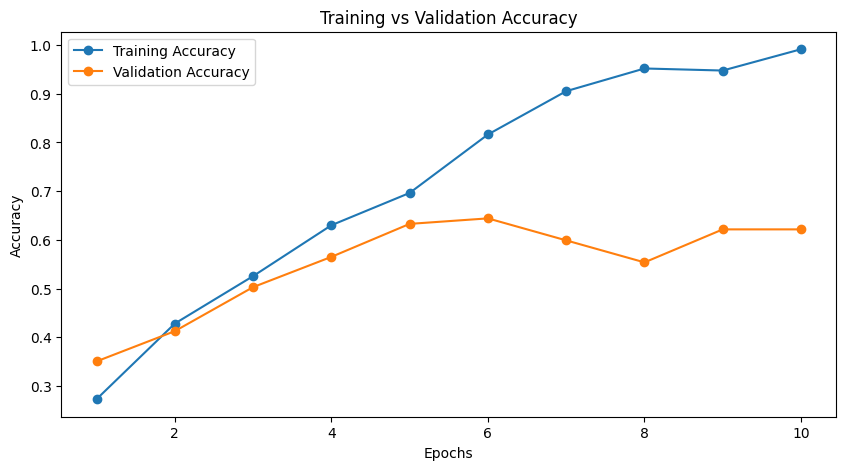

In [15]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, EPOCHS + 1)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# For EPOCHS = 20

In [16]:
EPOCHS = 20
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs =EPOCHS
    
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.9901 - loss: 0.0585 - val_accuracy: 0.6497 - val_loss: 1.6247
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.9901 - loss: 0.0568 - val_accuracy: 0.6215 - val_loss: 1.6584
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.9929 - loss: 0.0314 - val_accuracy: 0.6271 - val_loss: 1.9677
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.9958 - loss: 0.0421 - val_accuracy: 0.6610 - val_loss: 1.4697
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - accuracy: 0.9944 - loss: 0.0259 - val_accuracy: 0.6102 - val_loss: 2.1845
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.9958 - loss: 0.0301 - val_accuracy: 0.6667 - val_loss: 1.7846
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.9929 - loss: 0.0444 - val_accuracy: 0.6441 - val_loss: 1.7352
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - accuracy: 0.9944 - loss: 0.0258 - val_accuracy: 0.

We see acuuracy = 0.99 , but val_accuracy is 0.61 ariund , which shows the model is overfitting .


# Solve the overfitting Problem 

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor = 'val_loss', patience = 3)

In [18]:
from tensorflow.keras.callbacks import LearningRateScheduler

def scheduler(epoch, lr) :
    if epoch> 5 :
        return lr* 0.1
    return lr

lr_schedule = LearningRateScheduler(scheduler)

In [19]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

#Convolution layer 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation ='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

#Convolution layer 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation = 'relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

#Convolution layer 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation = 'relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Flattening 
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))

#FCL 
model.add(tf.keras.layers.Dense(128, activation = 'relu'))

#Output layer 
model.add(tf.keras.layers.Dense(num_classes, activation = 'softmax'))

In [20]:
model.compile(
    optimizer ='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [21]:
EPOCHS = 20

In [22]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS,
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 390ms/step - accuracy: 0.3743 - loss: 12.9100 - val_accuracy: 0.1186 - val_loss: 10.4078 - learning_rate: 0.0010
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.5664 - loss: 1.9884 - val_accuracy: 0.2825 - val_loss: 25.2916 - learning_rate: 0.0010
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.6511 - loss: 1.0254 - val_accuracy: 0.2712 - val_loss: 32.8005 - learning_rate: 0.0010
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.7373 - loss: 0.8251 - val_accuracy: 0.2542 - val_loss: 29.4552 - learning_rate: 0.0010


# Model with data Augmentation 
(trying for better results)

In [23]:
import tensorflow as tf
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom,
    Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    Flatten, Dropout, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [24]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomZoom(0.15),
])

In [25]:


# -------------------------------
# Data Augmentation (Critical fix)
# -------------------------------


# -------------------------------
# Build the Model
# -------------------------------
model = tf.keras.models.Sequential()

# Input + Augmentation + Rescaling
model.add(data_augmentation)
model.add(Rescaling(1.0/255, input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

# Conv Block 1
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))  # Extra layer for better features
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 3
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.35))

# Classifier
model.add(Flatten())

model.add(Dense(256, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes, activation="softmax"))

# -------------------------------
# Compile with lower initial LR
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------
# Callbacks
# -------------------------------
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,           # More patient now that we have augmentation
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Halve LR when plateau
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# -------------------------------
# Train the model
# -------------------------------
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,  # Allow more epochs since early stopping will protect us
    callbacks=callbacks,
    verbose=1
)

# Optional: Print final results
print("\nTraining complete!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50


E0000 00:00:1779970809.488076      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_3_1/dropout_4_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 263ms/step - accuracy: 0.3121 - loss: 2.9588 - val_accuracy: 0.2429 - val_loss: 2.9832 - learning_rate: 3.0000e-04
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - accuracy: 0.4153 - loss: 2.6331 - val_accuracy: 0.2316 - val_loss: 3.6946 - learning_rate: 3.0000e-04
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.4407 - loss: 2.5363 - val_accuracy: 0.2429 - val_loss: 5.0196 - learning_rate: 3.0000e-04
Epoch 4/50
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5108 - loss: 2.4200
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.4958 - loss: 2.4256 - val_accuracy: 0.2881 - val_loss: 4.5176 - learning_rate: 3.0000e-04
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.4661 - loss: 2.4524 - val_accuracy: 0.0904 - val_loss: 5.2966 - learning_rate: 1.5000e-04
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.5099 - loss: 

there is still a room for improovement so, lets try transfr learning models

# Transfer Learning 

## MobileNetV2

In [26]:
# base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (224,224, 3),
    include_top =False,
    weights = 'imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
base_model.trainable = False

model = tf.keras.models.Sequential()

model.add(tf.keras.Input( shape=(224,224,3)))
model.add(data_augmentation)
model.add(tf.keras.layers.Rescaling(1.0/255))

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation = 'relu'))
model.add(tf.keras.layers.Dense(num_classes, activation = 'softmax'))

In [28]:
model.compile(
    optimizer ='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [29]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 275ms/step - accuracy: 0.4548 - loss: 1.4604 - val_accuracy: 0.5932 - val_loss: 1.0594
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - accuracy: 0.6780 - loss: 0.8851 - val_accuracy: 0.6441 - val_loss: 0.8951
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.7359 - loss: 0.7381 - val_accuracy: 0.6723 - val_loss: 0.8129
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.7924 - loss: 0.6050 - val_accuracy: 0.7288 - val_loss: 0.7299
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.7641 - loss: 0.6228 - val_accuracy: 0.7288 - val_loss: 0.8250
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.8121 - loss: 0.5741 - val_accuracy: 0.6836 - val_loss: 0.8682
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.8305 - loss: 0.5174 - val_accuracy: 0.6328 - val_loss: 0.9259
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.8404 - loss: 0.4468 - val_accuracy: 0

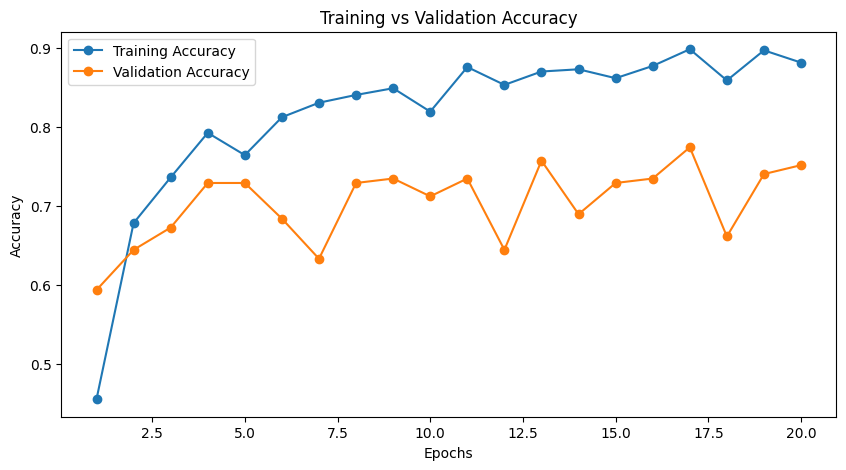

In [31]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, 21)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [32]:
model.save('/kaggle/working/my_model.keras')

## EfficientNetB0

In [33]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input 

In [34]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir, 
    validation_split = 0.2,
    subset = 'training',
    image_size = (IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [35]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = 'validation',
    image_size = (IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [36]:
class_names = train_dataset.class_names
print(class_names)
num_classes = len(class_names)
print(num_classes)

['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
6


In [37]:
class_counts = {}
total_images =0

for class_name in class_names :
    class_path = os.path.join(data_dir, class_name)
    count = len(os.listdir(class_path))
    class_counts[class_name] = count
    total_images += count
    

In [38]:
class_weights = {}

for index, class_name in enumerate(class_names):
  class_weights[index] = total_images / (num_classes * class_counts[class_name])

print("Class weights", class_weights)

Class weights {0: 0.7530224525043178, 1: 0.7491408934707904, 2: 0.7649122807017544, 3: 1.4110032362459546, 4: 2.106280193236715, 5: 1.1815718157181572}


In [39]:
data_augmentation = tf.keras.Sequential()
data_augmentation.add(tf.keras.layers.RandomFlip("horizontal"))
data_augmentation.add(tf.keras.layers.RandomRotation(0.1))
data_augmentation.add(tf.keras.layers.RandomZoom(0.1))

In [40]:
train_images = []
train_labels = []
for images, labels in train_dataset:
  images = preprocess_input(images)
  train_images.append(images)
  train_labels.append(labels)

train_images = tf.concat(train_images, axis=0)
train_labels = tf.concat(train_labels, axis=0)



In [41]:
validation_images = []
validation_labels = []

for images, labels in validation_dataset:
  images = preprocess_input(images)
  validation_images.append(images)
  validation_labels.append(labels)

validation_images = tf.concat(validation_images, axis=0)
validation_labels = tf.concat(validation_labels, axis=0)

In [42]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape = (224,224,3),
    include_top = False,
    weights="imagenet"
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [43]:
base_model.trainable = False

In [44]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape = (224,224,3)))
model.add(data_augmentation)

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation = 'relu'))
model.add(tf.keras.layers.Dense(num_classes, activation = 'softmax'))

In [45]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [47]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 15
)

Epoch 1/15


E0000 00:00:1779970970.690026      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_6_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 301ms/step - accuracy: 0.5127 - loss: 1.2781 - val_accuracy: 0.5932 - val_loss: 0.9822
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.7472 - loss: 0.7514 - val_accuracy: 0.6949 - val_loss: 0.8281
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.8037 - loss: 0.6179 - val_accuracy: 0.7006 - val_loss: 0.7819
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.8319 - loss: 0.4917 - val_accuracy: 0.7571 - val_loss: 0.7008
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.8588 - loss: 0.4333 - val_accuracy: 0.7288 - val_loss: 0.6879
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.8771 - loss: 0.3748 - val_accuracy: 0.7514 - val_loss: 0.6902
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.8842 - loss: 0.3492 - val_accuracy: 0.7288 - val_loss: 0.6733
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.9082 - loss: 0.3258 - val_accuracy: 0.7627 - val

This time we have got :

1. accuracy = 0.9435 and validation accuracy = 0.81.

which is much better than earlier, so now lets try doing Hyperparameter Optimization (HPO).

# Hyper Parameter Optimization

In [48]:

import keras_tuner as kt
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Reuse your train_dataset and validation_dataset (with preprocess_input already applied)
# Make sure they are defined as in your original code

def build_model(hp):
    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(hp.Float("rotation_factor", min_value=0.05, max_value=0.3, step=0.05)),
        RandomZoom(hp.Float("zoom_factor", min_value=0.05, max_value=0.3, step=0.05)),
        base_model,
        GlobalAveragePooling2D(),
        Dropout(hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)),
        Dense(
            hp.Int("dense_units", min_value=64, max_value=512, step=64),
            activation='relu'
        ),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Setup Random Search Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,          # Same as n_iter before
    executions_per_trial=1,
    directory='kt_dir',
    project_name='efficientnet_tune',
    overwrite=True
)

# Optional: Early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Run the search
tuner.search(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights  # Handles imbalance
)

# Results
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hps.values)

best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on validation
val_loss, val_acc = best_model.evaluate(validation_dataset)
print(f"Best validation accuracy: {val_acc:.4f}")

Trial 20 Complete [00h 01m 38s]
val_accuracy: 0.7740113139152527

Best val_accuracy So Far: 0.8305084705352783
Total elapsed time: 00h 32m 24s
Best hyperparameters:
{'rotation_factor': 0.25, 'zoom_factor': 0.05, 'dropout_rate': 0.0, 'dense_units': 320, 'learning_rate': 0.0010438306464659397}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.8305 - loss: 0.6033
Best validation accuracy: 0.8305


In [60]:
model.save('my_model1.keras')

In [65]:
with open("class_names.txt", "w") as f:
    for name in class_names:
        f.write(name + "\n")